In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Data Loadings and Preprocessing

In [74]:
aapl_df = yf.download("AAPL", start = "2021-09-01", end = "2023-09-30")['Close']
aapl_df = aapl_df['AAPL']
aapl_df.head()

[*********************100%***********************]  1 of 1 completed


,AAPL
Date,
2021-09-01,148.882156
2021-09-02,149.995041
2021-09-03,150.629578
2021-09-07,152.962708
2021-09-08,151.420319


In [75]:
msft_df = yf.download("MSFT", start = "2021-09-01", end = "2023-09-30")['Close']
msft_df = msft_df['MSFT']
msft_df.head()

[*********************100%***********************]  1 of 1 completed


,MSFT
Date,
2021-09-01,290.219818
2021-09-02,289.565979
2021-09-03,289.556396
2021-09-07,288.633270
2021-09-08,288.662079


In [76]:
amzn_df = yf.download("AMZN", start = "2021-09-01", end = "2023-09-30")['Close']
amzn_df = amzn_df['AMZN']
amzn_df.head()

[*********************100%***********************]  1 of 1 completed


,AMZN
Date,
2021-09-01,173.949997
2021-09-02,173.156006
2021-09-03,173.902496
2021-09-07,175.464493
2021-09-08,176.274994


In [77]:
aapl_smoothed_df = aapl_df.rolling(window = 5).mean().dropna()
msft_smoothed_df = msft_df.rolling(window = 5).mean().dropna()
amzn_smoothed_df = amzn_df.rolling(window = 5).mean().dropna()

# Data Splitting

In [78]:
aapl_train_idx = int(len(aapl_smoothed_df)*0.8)
aapl_train = aapl_smoothed_df[:aapl_train_idx]
aapl_test = aapl_smoothed_df[aapl_train_idx:]

In [79]:
msft_train_idx = int(len(msft_smoothed_df)*0.8)
msft_train = msft_smoothed_df[:msft_train_idx]
msft_test = msft_smoothed_df[msft_train_idx:]

In [80]:
amzn_train_idx = int(len(amzn_smoothed_df)*0.8)
amzn_train = amzn_smoothed_df[:amzn_train_idx]
amzn_test = amzn_smoothed_df[amzn_train_idx:]

# Data Transformation

In [81]:
aapl_scaler = MinMaxScaler()
aapl_train_scaled = aapl_scaler.fit_transform(aapl_train.to_frame())
aapl_test_scaled = aapl_scaler.transform(aapl_test.to_frame())

In [82]:
msft_scaler = MinMaxScaler()
msft_train_scaled = msft_scaler.fit_transform(msft_train.to_frame())
msft_test_scaled = msft_scaler.transform(msft_test.to_frame())

In [83]:
amzn_scaler = MinMaxScaler()
amzn_train_scaled = amzn_scaler.fit_transform(amzn_train.to_frame())
amzn_test_scaled = amzn_scaler.transform(amzn_test.to_frame())

# Create Sequences

In [84]:
def create_sequences(dataset, time_steps):
  x, y = [], []
  for i in range(len(dataset) - time_steps):
    x.append(dataset[i:i+time_steps])
    y.append(dataset[i+time_steps])
  return np.array(x), np.array(y)

In [85]:
aapl_X_train, aapl_y_train = create_sequences(aapl_train_scaled, 5)
aapl_X_test, aapl_y_test = create_sequences(aapl_test_scaled, 5)
aapl_X_train = np.reshape(aapl_X_train, (aapl_X_train.shape[0], aapl_X_train.shape[1], 1))
aapl_X_test = np.reshape(aapl_X_test, (aapl_X_test.shape[0], aapl_X_test.shape[1], 1))

In [86]:
msft_X_train, msft_y_train = create_sequences(msft_train_scaled, 5)
msft_X_test, msft_y_test = create_sequences(msft_test_scaled, 5)
msft_X_train = np.reshape(msft_X_train, (msft_X_train.shape[0], msft_X_train.shape[1], 1))
msft_X_test = np.reshape(msft_X_test, (msft_X_test.shape[0], msft_X_test.shape[1], 1))

In [87]:
amzn_X_train, amzn_y_train = create_sequences(amzn_train_scaled, 5)
amzn_X_test, amzn_y_test = create_sequences(amzn_test_scaled, 5)
amzn_X_train = np.reshape(amzn_X_train, (amzn_X_train.shape[0], amzn_X_train.shape[1], 1))
amzn_X_test = np.reshape(amzn_X_test, (amzn_X_test.shape[0], amzn_X_test.shape[1], 1))

# Model Training - LSTM

## Apple

In [88]:
aapl_model = Sequential()
aapl_model.add(LSTM(64, activation = "tanh", kernel_regularizer = l2(0.001), input_shape = (aapl_X_train.shape[1], 1)))
aapl_model.add(Dense(25, kernel_regularizer = l2(0.001)))
aapl_model.add(Dense(1))
aapl_model.compile(optimizer = Adam(learning_rate = 0.001), loss = "mse", metrics = ['mse'])
aapl_history = aapl_model.fit(aapl_X_train,
                              aapl_y_train,
                              validation_split = 0.1,
                              batch_size = 64,
                              epochs = 200,
                              verbose = 1)



Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.3343 - mse: 0.2965 - val_loss: 0.2542 - val_mse: 0.2165
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1357 - mse: 0.0981 - val_loss: 0.0695 - val_mse: 0.0319
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0557 - mse: 0.0180 - val_loss: 0.0461 - val_mse: 0.0085
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0685 - mse: 0.0311 - val_loss: 0.0445 - val_mse: 0.0074
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0534 - mse: 0.0165 - val_loss: 0.0401 - val_mse: 0.0036
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0475 - mse: 0.0113 - val_loss: 0.0490 - val_mse: 0.0131
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0483 - mse: 0.0125 - val_loss: 0.0452 - val_mse: 0.0097
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0444 - mse: 0.0091 - val_loss: 0.0378 - val_mse: 0.0027
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0424 - mse: 

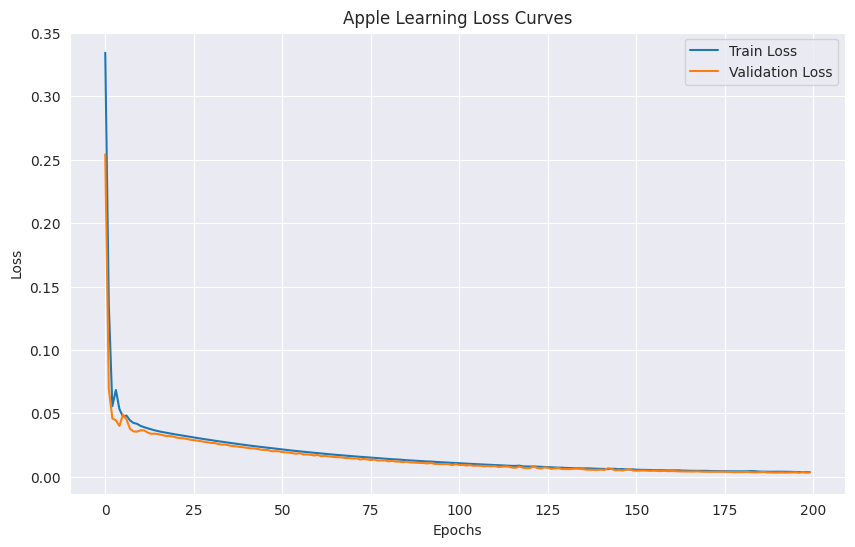

In [89]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 6))
plt.plot(aapl_history.history['loss'], label = "Train Loss")
plt.plot(aapl_history.history['val_loss'], label = "Validation Loss")
plt.title("Apple Learning Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

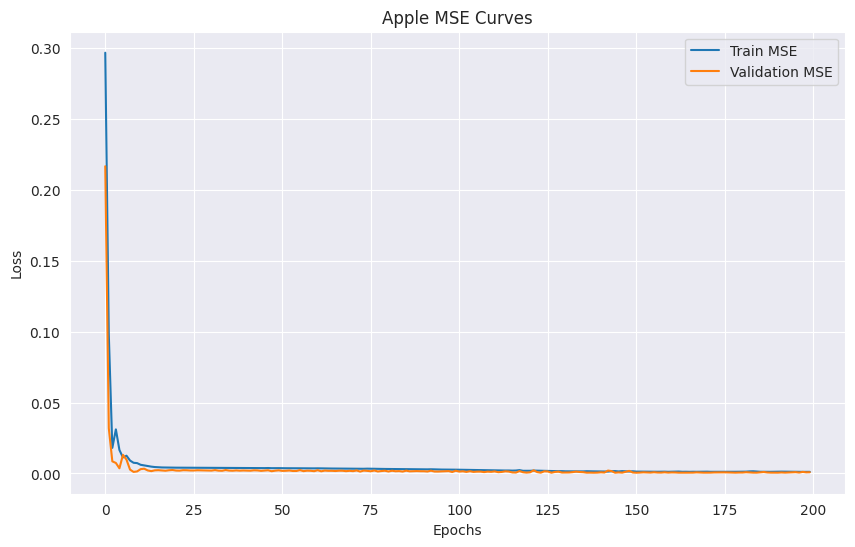

In [90]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 6))
plt.plot(aapl_history.history['mse'], label = "Train MSE")
plt.plot(aapl_history.history['val_mse'], label = "Validation MSE")
plt.title("Apple MSE Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Microsoft

In [91]:
msft_model = Sequential()
msft_model.add(LSTM(64, activation = "tanh", kernel_regularizer = l2(0.001), input_shape = (msft_X_train.shape[1], 1)))
msft_model.add(Dense(25, kernel_regularizer = l2(0.001)))
msft_model.add(Dense(1))
msft_model.compile(optimizer = Adam(learning_rate = 0.001), loss = "mse", metrics = ['mse'])
msft_history = msft_model.fit(msft_X_train,
                              msft_y_train,
                              validation_split = 0.1,
                              batch_size = 64,
                              epochs = 200,
                              verbose = 1)



Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.1841 - mse: 0.1473 - val_loss: 0.0796 - val_mse: 0.0429
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0633 - mse: 0.0266 - val_loss: 0.0406 - val_mse: 0.0040
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0562 - mse: 0.0198 - val_loss: 0.0484 - val_mse: 0.0123
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0507 - mse: 0.0149 - val_loss: 0.0371 - val_mse: 0.0017
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0421 - mse: 0.0071 - val_loss: 0.0398 - val_mse: 0.0052
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0427 - mse: 0.0084 - val_loss: 0.0386 - val_mse: 0.0046
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0392 - mse: 0.0054 - val_loss: 0.0351 - val_mse: 0.0016
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0374 - mse: 0.0042 - val_loss: 0.0341 - val_mse: 0.0013
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0363 - mse: 

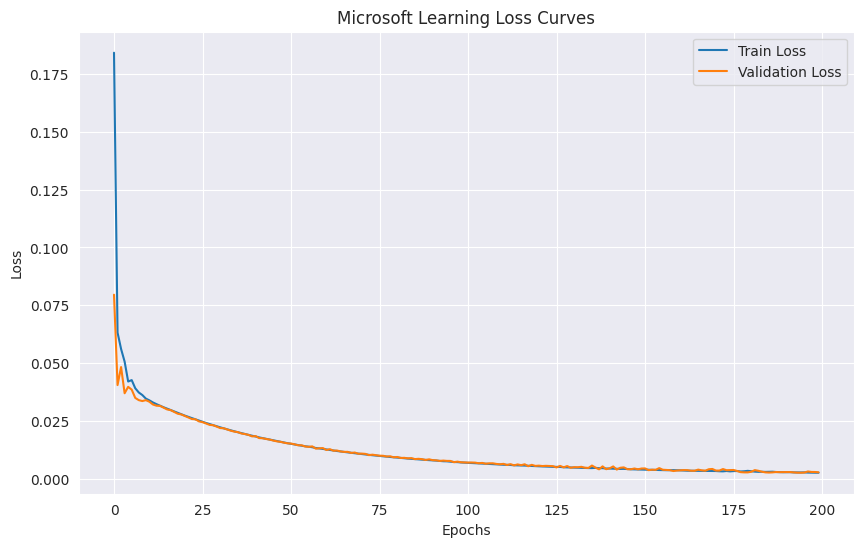

In [92]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 6))
plt.plot(msft_history.history['loss'], label = "Train Loss")
plt.plot(msft_history.history['val_loss'], label = "Validation Loss")
plt.title("Microsoft Learning Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

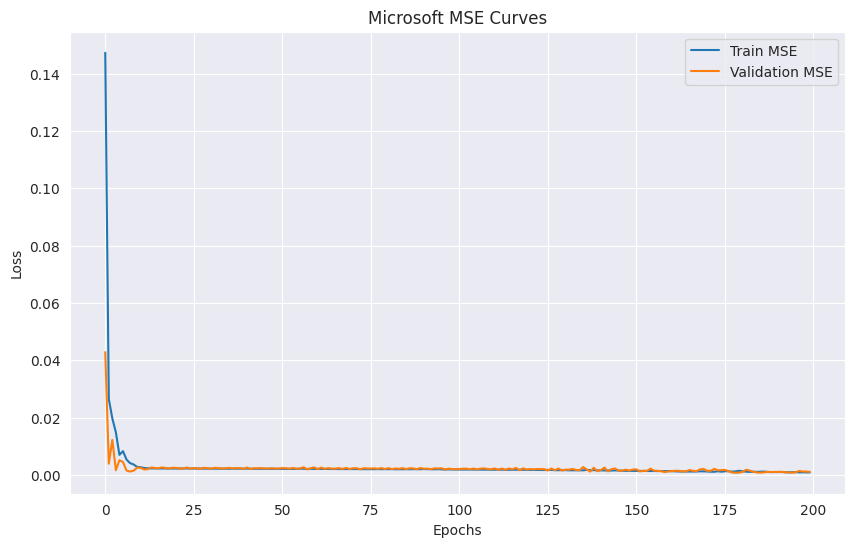

In [93]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 6))
plt.plot(msft_history.history['mse'], label = "Train MSE")
plt.plot(msft_history.history['val_mse'], label = "Validation MSE")
plt.title("Microsoft MSE Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Amazon

In [94]:
amzn_model = Sequential()
amzn_model.add(LSTM(64, activation = "tanh", kernel_regularizer = l2(0.001), input_shape = (amzn_X_train.shape[1], 1)))
amzn_model.add(Dense(25, kernel_regularizer = l2(0.001)))
amzn_model.add(Dense(1))
amzn_model.compile(optimizer = Adam(learning_rate = 0.001), loss = "mse", metrics = ['mse'])
amzn_history = amzn_model.fit(amzn_X_train,
                              amzn_y_train,
                              validation_split = 0.1,
                              batch_size = 64,
                              epochs = 200,
                              verbose = 1)



Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.3007 - mse: 0.2637 - val_loss: 0.0403 - val_mse: 0.0034
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1229 - mse: 0.0859 - val_loss: 0.0449 - val_mse: 0.0079
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0540 - mse: 0.0170 - val_loss: 0.0778 - val_mse: 0.0408
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0672 - mse: 0.0304 - val_loss: 0.0698 - val_mse: 0.0332
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0510 - mse: 0.0147 - val_loss: 0.0477 - val_mse: 0.0117
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0466 - mse: 0.0108 - val_loss: 0.0403 - val_mse: 0.0048
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0461 - mse: 0.0107 - val_loss: 0.0396 - val_mse: 0.0045
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0415 - mse: 0.0065 - val_loss: 0.0409 - val_mse: 0.0062
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0399 - mse: 

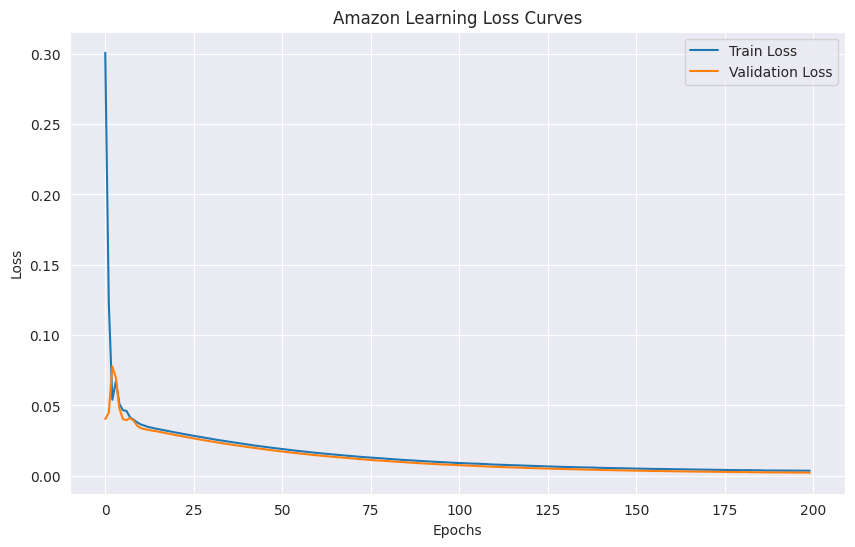

In [95]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 6))
plt.plot(amzn_history.history['loss'], label = "Train Loss")
plt.plot(amzn_history.history['val_loss'], label = "Validation Loss")
plt.title("Amazon Learning Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

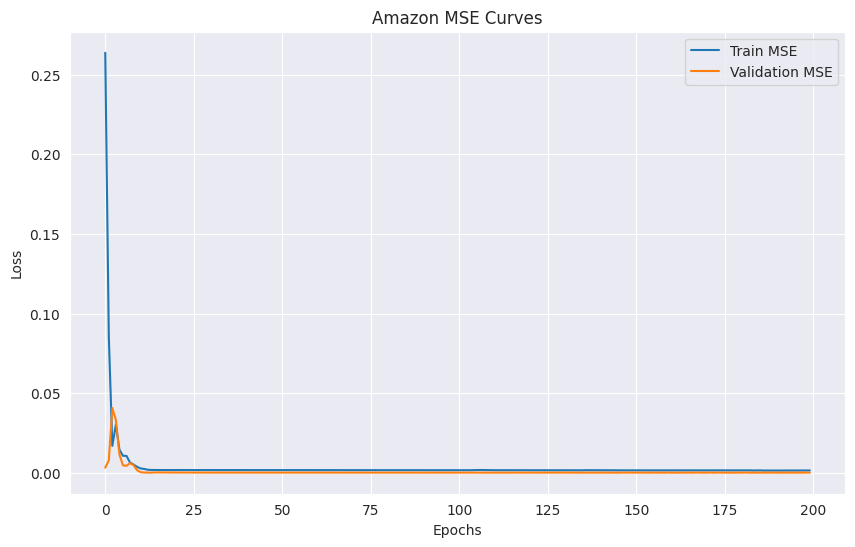

In [96]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 6))
plt.plot(amzn_history.history['mse'], label = "Train MSE")
plt.plot(amzn_history.history['val_mse'], label = "Validation MSE")
plt.title("Amazon MSE Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Model Evaluation

## Apple

In [97]:
aapl_predictions = aapl_model.predict(aapl_X_test)
aapl_predictions = aapl_scaler.inverse_transform(aapl_predictions)
aapl_y_test = aapl_scaler.inverse_transform(aapl_y_test.reshape(-1, 1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [98]:
aapl_rmse = np.sqrt(mean_squared_error(aapl_y_test, aapl_predictions))
aapl_r2 = r2_score(aapl_y_test, aapl_predictions)
print("APPLE RMSE: {:.4f}".format(aapl_rmse))
print("AAPLE R2: {:.4f}".format(aapl_r2))

APPLE RMSE: 1.9974
AAPLE R2: 0.9195


In [99]:
aapl_y_test_df = pd.Series(aapl_y_test.flatten())
aapl_predictions_df = pd.Series(aapl_predictions.flatten())

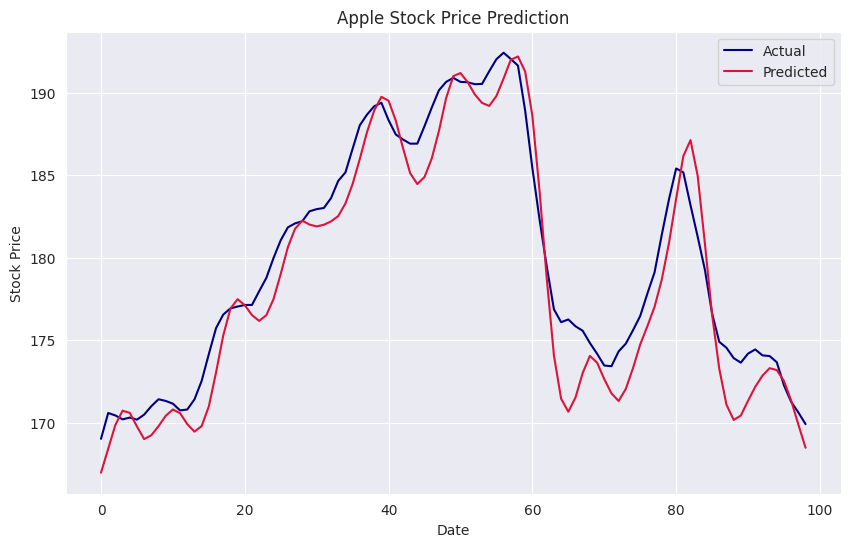

In [100]:
plt.figure(figsize = (10, 6))
aapl_y_test_df.plot(kind = "line", color = "navy", label = "Actual")
aapl_predictions_df.plot(kind = "line", color = "crimson", label = "Predicted")
plt.title("Apple Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

## Microsoft

In [101]:
msft_predictions = msft_model.predict(msft_X_test)
msft_predictions = msft_scaler.inverse_transform(msft_predictions)
msft_y_test = msft_scaler.inverse_transform(msft_y_test.reshape(-1, 1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [102]:
msft_rmse = np.sqrt(mean_squared_error(msft_y_test, msft_predictions))
msft_r2 = r2_score(msft_y_test, msft_predictions)
print("Microsoft RMSE: {:.4f}".format(msft_rmse))
print("Microsoft R2: {:.4f}".format(msft_r2))

Microsoft RMSE: 2.4354
Microsoft R2: 0.9375


In [103]:
msft_y_test_df = pd.Series(msft_y_test.flatten())
msft_predictions_df = pd.Series(msft_predictions.flatten())

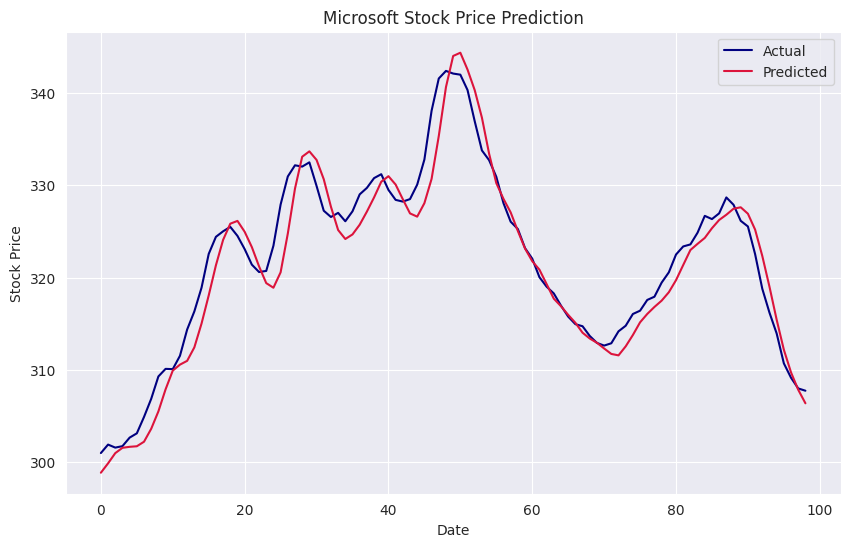

In [104]:
plt.figure(figsize = (10, 6))
msft_y_test_df.plot(kind = "line", color = "navy", label = "Actual")
msft_predictions_df.plot(kind = "line", color = "crimson", label = "Predicted")
plt.title("Microsoft Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

## Amazon

In [105]:
amzn_predictions = amzn_model.predict(amzn_X_test)
amzn_predictions = amzn_scaler.inverse_transform(amzn_predictions)
amzn_y_test = amzn_scaler.inverse_transform(amzn_y_test.reshape(-1, 1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [106]:
amzn_rmse = np.sqrt(mean_squared_error(amzn_y_test, amzn_predictions))
amzn_r2 = r2_score(amzn_y_test, amzn_predictions)
print("Amazon RMSE: {:.4f}".format(amzn_rmse))
print("Amazon R2: {:.4f}".format(amzn_r2))

Amazon RMSE: 2.3585
Amazon R2: 0.9195


In [107]:
amzn_y_test_df = pd.Series(amzn_y_test.flatten())
amzn_predictions_df = pd.Series(amzn_predictions.flatten())

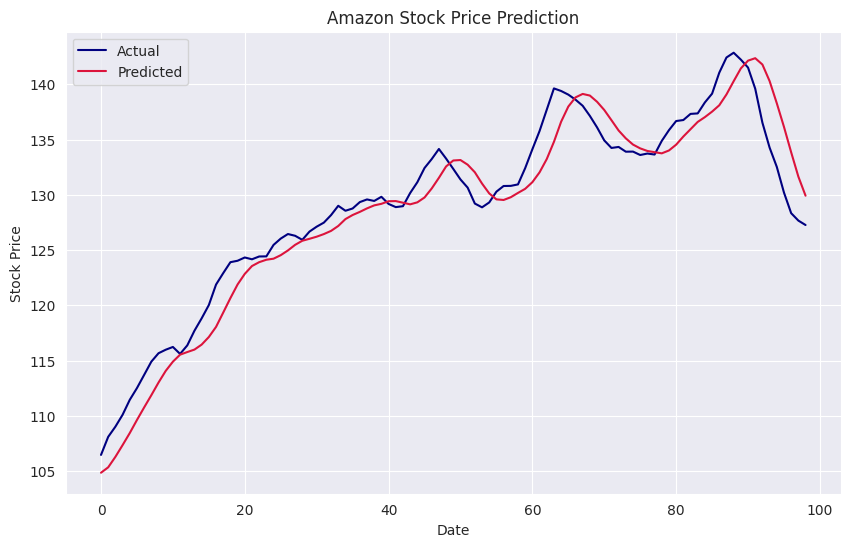

In [108]:
plt.figure(figsize = (10, 6))
amzn_y_test_df.plot(kind = "line", color = "navy", label = "Actual")
amzn_predictions_df.plot(kind = "line", color = "crimson", label = "Predicted")
plt.title("Amazon Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()